# [Encuesta de satisfacción en Google Form](https://forms.gle/YUc83ygwGoEcHgM2A) 

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/tools_numpy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/tools_numpy.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

### [Video de apoyo a la lectura interactiva y experimental de este cuaderno]()

### [Vínculo al programa del curso Deep Learning par Administración de Empresas:]()



Un reconocimiento a mis estudiantes que han construido conmigo este saber pedagógico:

<img src = 'https://github.com/marco-canas/intro_ml_dl/blob/main/5_images/taller_estructuras_datos_python_2025-09-04%20a%20las%2020.38.jpg?raw=true' width = 500> 



In [ ]:
import pandas as pd
import numpy as np

# Cargar la lista de estudiantes desde el archivo CSV
path = 'C:/Users/marco/Documentos/docencia/groups_list/g_lideres.xlsx'
df = pd.read_excel(path)

df.head(3)


# Principios de mi labor docente

## Modelo general de clase: [aula invertida](https://www3.gobiernodecanarias.org/medusa/ecoescuela/pedagotic/aprendizaje-invertido-flipped-classroom/)

<img src = 'https://resources.maneuveringthemiddle.com/wp-content/uploads/2020/07/04212706/1-5.png' width = 500>  



# Metodología de Aprendizaje Basado en Problemas y Proyectos (ABPP) 



<img src = 'https://www.unir.net/wp-content/uploads/2020/07/aprendizaje-problemas2-1-1-1-1.jpeg' width = 500>

# Desarrollo del pensamiento computacional con Lenguajes Python y R, y con archivos Markdown orientado a la formación en ciencia de datos 




<img src = 'https://i.ytimg.com/vi/mcG_wcR4e6M/maxresdefault.jpg' width = 200>

# Principio de fomento a la ciencia abierta, enseñar en el acceso a los datos públicos y el uso de software de código abierto  



<img src = 'https://unesdoc.unesco.org/in/rest/Thumb/image?id=p%3A%3Ausmarcdef_0000379949_spa&author=UNESCO&title=Recomendaci%C3%B3n+de+la+UNESCO+sobre+la+Ciencia+Abierta&year=2021&publisher=UNESCO&TypeOfDocument=UnescoPhysicalDocument&mat=PGD&ct=true&size=512&isPhysical=1' width = 200>

El enfoque STEAMS en educación preescolar, primaria y secundaria es una extensión del enfoque STEM (Ciencia, Tecnología, Ingeniería y Matemáticas) y su variante STEAM, que incorpora el Arte. 

En educación preescolar, primaria, secundaria y superior, se adapta a las diferentes etapas de desarrollo cognitivo y emocional de los estudiantes, promoviendo el aprendizaje activo y contextualizado.  



<img src = 'https://www.campuseducacion.com/blog/wp-content/uploads/2023/03/foto01-1.jpg' width = 200>

# Página 492 del Géron.   



## Building an Image Classifier Using the Sequential API  



# **Resumen completo y estructurado** del texto de *Aurélien Géron* sobre **“Building an Image Classifier Using the Sequential API”**,   

Tomado del libro *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (Cap. 10):

---



## **1. Carga del conjunto de datos Fashion MNIST**



* **Fashion MNIST** es una versión más desafiante del clásico MNIST: contiene **70,000 imágenes en escala de grises de 28×28 píxeles** de ropa y accesorios (10 clases distintas).
* Se carga fácilmente desde `tf.keras.datasets.fashion_mnist`.
* Se divide en **55,000 imágenes para entrenamiento**, **5,000 para validación**, y **10,000 para prueba**.
* Los valores de los píxeles (0–255) se **escalan al rango [0, 1]** dividiendo entre 255.


In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import numpy as np


In [ ]:

# Cargar los datos por medio de asignación múltiple 
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()  


In [4]:


# Dividir el conjunto de entrenamiento completo en entrenamiento y validación
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

In [5]:
# Escalamos los datos con la técnica de normalización 

X_train, X_valid, X_test = X_train/255., X_valid/255., X_test/255.




* Las clases se representan con nombres descriptivos:


In [20]:
nombres_clases = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
   "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
  




## Los nombres de las clases de imágenes en español    




## **2. Creación del modelo con la API Secuencial**

El modelo es un **perceptrón multicapa (MLP)** con dos capas ocultas.


In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])


c:\Users\marco\Documentos\investigacion\intro_ml_dl\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# grafica de relu

In [ ]:
# grafico de softmax 


**Estructura:**

* `Flatten`: convierte la imagen 28×28 en un vector de 784 elementos.
* Dos capas `Dense` con activación **ReLU** (rectified linear unit).
* Capa de salida `Dense(10, softmax)` para clasificación multiclase.



**Resumen del modelo (`model.summary()`):**

* Total de parámetros entrenables: **266,610**
  (784×300 + 300 + 300×100 + 100 + 100×10 + 10)

---



### **3. Compilación del modelo**

Se define la **función de pérdida**, el **optimizador** y las **métricas**:


In [7]:

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)




* `sparse_categorical_crossentropy`: adecuada cuando las etiquetas son índices de clase (0–9).
* `sgd`: descenso de gradiente estocástico.
* Métrica principal: **exactitud (accuracy)**.

---



## **4. Entrenamiento y validación**

El modelo se entrena con 30 épocas usando `fit()`:


In [8]:
%%time 
history = model.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_valid, y_valid)
)



Epoch 1/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7696 - loss: 0.7120 - val_accuracy: 0.8308 - val_loss: 0.5046
Epoch 2/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8305 - loss: 0.4884 - val_accuracy: 0.8548 - val_loss: 0.4361
Epoch 3/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8457 - loss: 0.4438 - val_accuracy: 0.8606 - val_loss: 0.4220
Epoch 4/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8548 - loss: 0.4148 - val_accuracy: 0.8562 - val_loss: 0.4209
Epoch 5/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8606 - loss: 0.3963 - val_accuracy: 0.8674 - val_loss: 0.3854
Epoch 6/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8668 - loss: 0.3790 - val_accuracy: 0.8736 - val_loss: 0.3700
Epoch 7/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8707 - loss: 0.3669 - val_accuracy: 0.8788 - val_loss: 0.3552
Epoch 8/30
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8752 - loss: 0.3542 - 


* **Cada época** recorre todo el conjunto de entrenamiento en mini-lotes de 32 ejemplos.
* Se mide la pérdida y la exactitud tanto en entrenamiento como en validación.
* Se observa un **ligero sobreajuste** (train acc ≈ 92%, val acc ≈ 89%).

---


# Sobre la función de pérdida loss  


Cuando ejecutas este código en TensorFlow/Keras:


In [ ]:

history = model.fit(
    X_train, y_train,
    epochs=30,
    validation_data=(X_valid, y_valid)
)




el **modelo entrena** durante 30 épocas sobre los datos de entrenamiento y evalúa su desempeño en cada época tanto sobre el conjunto de **entrenamiento** como sobre el de **validación**.
Y uno de los valores más importantes que se calcula en cada época es precisamente el **"loss"**.

---



### 🔹 ¿Qué significa el *loss*?

**El “loss” (o función de pérdida)** mide **cuánto se equivoca el modelo** en sus predicciones respecto a las etiquetas verdaderas.
Es una **medida del error global** del modelo en esa época.



En términos formales:

$$
\text{Loss} = \frac{1}{N} \sum_{i=1}^{N} L(\hat{y}_i, y_i)
$$

donde

* $ L(\hat{y}_i, y_i) $ es la **función de pérdida individual** (por ejemplo, *categorical crossentropy*),
* $ \hat{y}_i $ es la predicción del modelo,
* $ y_i $ es el valor real,
* $ N $ es el número de muestras.

---



### 🔹 Tipos de *loss* según la tarea

| Tipo de tarea                | Función de pérdida más común                                   | Significado                                                           |
| ---------------------------- | -------------------------------------------------------------- | --------------------------------------------------------------------- |
| **Clasificación multiclase** | `categorical_crossentropy` o `sparse_categorical_crossentropy` | Penaliza cuando la probabilidad asignada a la clase correcta es baja. |
| **Regresión**                | `mean_squared_error (MSE)`                                     | Penaliza más los errores grandes; mide la distancia cuadrática media. |
| **Binaria (sí/no)**          | `binary_crossentropy`                                          | Mide la discrepancia entre probabilidades y etiquetas 0/1.            |

---



### 🔹 Pérdida de entrenamiento vs. pérdida de validación

Durante el entrenamiento, Keras reporta dos valores por época:

* **`loss`** → Error sobre los datos de **entrenamiento**.
* **`val_loss`** → Error sobre los datos de **validación**, que el modelo no ha visto durante el ajuste.

| Época                      | loss (train)                                                                                               | val_loss (validación) | Interpretación |
| -------------------------- | ---------------------------------------------------------------------------------------------------------- | --------------------- | -------------- |
| Disminuyen ambos           | ✅ Buen aprendizaje                                                                                         |                       |                |
| `loss ↓` pero `val_loss ↑` | ⚠️ **Sobreajuste (overfitting)**: el modelo memoriza el entrenamiento y pierde capacidad de generalización |                       |                |
| Ambos altos                | ❌ Modelo subentrenado o arquitectura/pérdida inadecuada                                                    |                       |                |

---

### 🔹 Ejemplo visual con `history`

Puedes graficar la evolución del *loss* para analizar el entrenamiento:


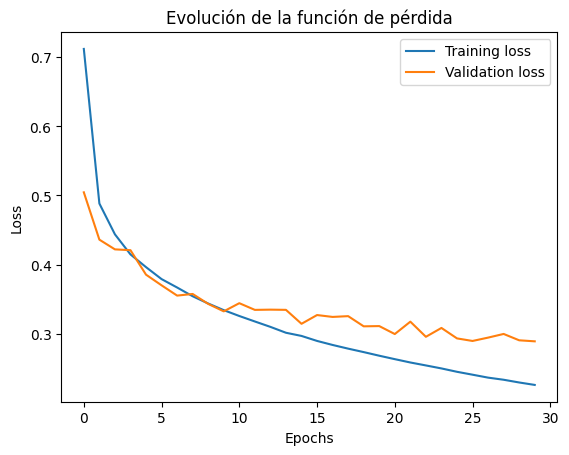

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Evolución de la función de pérdida")
plt.show()




Esto te permitirá **ver si el modelo está aprendiendo correctamente** o si necesita ajustes (más datos, regularización, dropout, etc.).

---



## **5. Curvas de aprendizaje**



Se visualizan las métricas almacenadas en `history.history` con Pandas y Matplotlib:


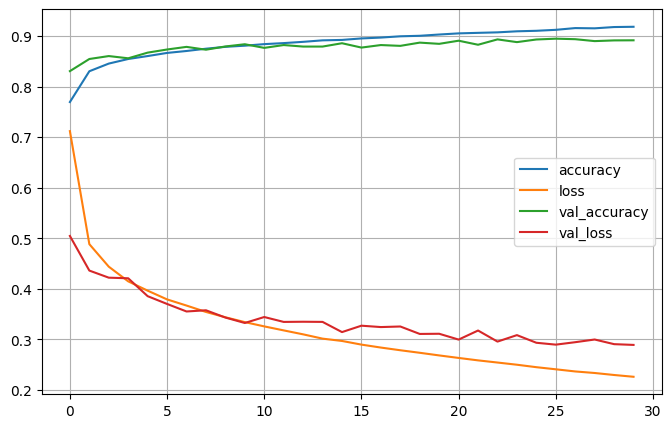

In [11]:
import pandas as pd 
pd.DataFrame(history.history).plot(figsize=(8,5), grid=True)
plt.savefig(r"C:\Users\marco\Downloads\hitory.jpg")
plt.show()




* Las curvas muestran que la pérdida disminuye y la precisión aumenta con las épocas.
* La separación entre curvas de entrenamiento y validación indica leve sobreajuste.

---



### **6. Evaluación final**

Se evalúa el modelo con el conjunto de prueba:


In [12]:

model.evaluate(X_test, y_test)
# → loss: 0.3243, accuracy: 0.8864



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8823 - loss: 0.3261


[0.3261258900165558, 0.8823000192642212]


* El rendimiento en test suele ser ligeramente inferior al de validación.
* No se deben ajustar hiperparámetros usando el conjunto de prueba (para evitar sesgo optimista).

---



### **7. Predicción con el modelo**

Para obtener predicciones en nuevas imágenes:


In [14]:
X_new = X_test[:3]


In [17]:
y_proba = model.predict(X_new)
y_proba 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


array([[1.2448464e-06, 3.4369455e-07, 2.3274872e-06, 8.5012698e-06,
        2.1095989e-06, 3.7416939e-03, 3.1016341e-06, 1.7977249e-02,
        3.3135712e-04, 9.7793204e-01],
       [2.0724656e-05, 2.2021840e-09, 9.9517536e-01, 2.6926872e-09,
        4.7390461e-03, 4.3190135e-11, 6.4722342e-05, 5.5415085e-13,
        2.9230527e-08, 2.0809406e-14],
       [1.5680091e-05, 9.9998200e-01, 7.5552015e-07, 1.2707604e-06,
        2.0743877e-07, 1.3772000e-11, 1.8619616e-08, 4.1105108e-10,
        7.2195574e-09, 2.7015259e-09]], dtype=float32)

In [19]:
y_pred = y_proba.argmax(axis=-1) # argmax nos entrega el índice asociado al valor maximo en una arreglo 
y_pred 


array([9, 2, 1])

In [25]:
y_test[:3]

array([9, 2, 1], dtype=uint8)

In [24]:
[nombres_clases[i] for i in y_pred]

['Ankle boot', 'Pullover', 'Trouser']


* `predict()` devuelve probabilidades para cada clase.
* `argmax()` selecciona la clase con mayor probabilidad.
* Ejemplo de salida:

  ```
  ['Ankle boot', 'Pullover', 'Trouser']
  ```
* Las tres primeras imágenes del test fueron clasificadas correctamente.

---



### **8. Consideraciones finales**

* El modelo puede mejorarse ajustando **tasa de aprendizaje**, **optimizador**, **número de capas/neuronas**, o **tamaño del lote**.
* La **Sequential API** es ideal para redes simples de capas apiladas.
* Para arquitecturas más complejas, se usa la **Functional API** o la **Subclassing API** (explicadas más adelante en el libro).

---



### 💡 **Resumen en una frase**

Con la API Secuencial de Keras, se puede construir fácilmente un clasificador neuronal multicapa (MLP) para el conjunto de datos **Fashion MNIST**, entrenarlo con *SGD* y medir su desempeño, logrando cerca de **89% de precisión** en validación y demostrando el flujo completo de trabajo de una red neuronal básica: *cargar datos, normalizar, construir, compilar, entrenar, evaluar y predecir.*

---



¿Quieres que te haga un **mapa conceptual visual**. 


In [28]:
# Mapa conceptual de "Building an Image Classifier Using the Sequential API" (Aurélien Géron)
# Generado en Graphviz usando la librería `graphviz` para Python.
# Instrucciones:
# 1) Instala la librería de Python: pip install graphviz
# 2) Asegúrate de tener instalado Graphviz en el sistema (dot). En Windows, agrega la ruta bin a PATH.
# 3) Ejecuta este script: python mapa_conceptual_graphviz.py
#    Generará los archivos: mapa_conceptual (formato PNG) y mapa_conceptual (formato DOT temporal).

from graphviz import Digraph

dot = Digraph(name='MapaConceptual_FashionMNIST', format='png')
dot.attr(rankdir='LR', fontsize='12')

# Estilos generales
dot.attr('node', shape='rectangle', style='rounded,filled', fontname='Helvetica')

# Nodos principales
dot.node('Dataset', 'Dataset\nFashion MNIST\n(70,000, 28x28, 10 clases)')
dot.node('Preproc', 'Preprocessing\n/255.0 → [0,1]\nTrain/Valid/Test split')

dot.node('Model', 'Model\nSequential API\nMLP (clasificador)')

dot.node('Layers', 'Capas\nInput → Flatten → Dense x2 → Dense(softmax)')

dot.node('Compile', 'Compilar\nloss: sparse_categorical_crossentropy\noptimizer: SGD\nmetrics: accuracy')

dot.node('Train', 'Entrenamiento\nfit(X_train, y_train)\nepochs, batch_size, validation_data')

dot.node('Eval', 'Evaluación\nevaluate(X_test, y_test)\nestimate generalization')

dot.node('Predict', 'Predicción\npredict(X_new) → probabilidades\nargmax → etiquetas')

dot.node('Tuning', 'Ajuste de hiperparámetros\nlearning rate, optimizador, capas, neuronas, batch_size')

# Conexiones
dot.edge('Dataset', 'Preproc', label='cargar y revisar')
dot.edge('Preproc', 'Model', label='datos normalizados')

# Detalle de la arquitectura: expandir Layers en subgrafo
with dot.subgraph(name='cluster_layers') as c:
    c.attr(style='rounded', label='Arquitectura (detalle)')
    c.node('Input', 'Input\nshape=[28,28]')
    c.node('Flatten', 'Flatten\n→ vector 784')
    c.node('Dense1', 'Dense(300)\nactivation=ReLU\nparams: 784×300 + 300')
    c.node('Dense2', 'Dense(100)\nactivation=ReLU')
    c.node('Output', 'Dense(10)\nactivation=softmax')
    c.edges([('Input','Flatten'), ('Flatten','Dense1'), ('Dense1','Dense2'), ('Dense2','Output')])

# Conectar model -> layers (explicativo)
dot.edge('Model', 'Layers', label='usa')

# Flujo posterior
dot.edge('Model', 'Compile', label='compilar')
dot.edge('Compile', 'Train', label='entrenar')
dot.edge('Train', 'Eval', label='evaluar')
dot.edge('Eval', 'Predict', label='usar para nuevas instancias')

# Conectar tuning
dot.edge('Tuning', 'Train', label='ajusta antes de entrenar')
dot.edge('Tuning', 'Compile', label='p. ej. learning rate')

# Notas adicionales como nodos secundarios
dot.node('Overfit', 'Sobreajuste\ntrain >> val')
dot.edge('Train', 'Overfit', style='dashed')
dot.edge('Overfit', 'Tuning', label='regularizar/hyperparam')

# Renderizar y guardar archivo PNG
dot.render(filename='mapa_conceptual', cleanup=True, \
    directory=r"C:\Users\marco\Downloads")



'C:\\Users\\marco\\Downloads\\mapa_conceptual.png'

# Ahora, la implementación de estos conceptos a un problema de clasificación multiclase asociada a un problema de Administración de empresas en el contexto del Bajo Cauca Antioqueño.  



La **lectura interactiva y experimental** de los cuadernos Jupyter diseñados para el curso de **Fundamentos de Lógica** implica un enfoque dinámico y práctico para el aprendizaje, donde los estudiantes no solo consumen información teórica, sino que también interactúan con el contenido, modifican ejemplos, ejecutan código y experimentan con los conceptos lógicos en un entorno computacional. 

A continuación, se detallan las características clave de este enfoque:

---



### **1. Lectura Interactiva**  
- **Manipulación directa del contenido**: Los estudiantes pueden ejecutar celdas de código, modificar fórmulas lógicas o ejemplos, y observar cómo cambian los resultados en tiempo real.  
- **Visualización interactiva**: Uso de gráficos, diagramas (como árboles semánticos o tablas de verdad) o herramientas que respondan a entradas del usuario para ilustrar conceptos como validez, consistencia o inferencia.  
- **Retroalimentación inmediata**: Los cuadernos pueden incluir ejercicios con autoevaluación (ejecutando código que verifica soluciones) o explicaciones emergentes al resolver problemas.  

---



### **2. Lectura Experimental**  
- **Aprendizaje basado en prueba y error**: Los estudiantes pueden "jugar" con estructuras lógicas (por ejemplo, modificar conectores en una fórmula proposicional y ver cómo afecta su tabla de verdad).  
- **Simulación de escenarios**: Por ejemplo, modelar argumentos en lógica de primer orden y evaluar su corrección mediante ejecución de código (usando librerías como `sympy` o herramientas ad-hoc).  
- **Exploración guiada y abierta**: Se incluyen secciones con consignas del tipo *"¿Qué pasa si cambias este axioma?"* o *"Intenta construir un contraejemplo"* para fomentar la curiosidad.  

---



### **3. Componentes clave de los cuadernos**  
- **Fragmentos de código ejecutable**: Para evaluar expresiones lógicas, automatizar pruebas o implementar algoritmos (ej: verificación de tautologías).  
- **Celdas con texto teórico y preguntas reflexivas**: Integradas con ejemplos prácticos que requieren intervención activa (ej: *"Define aquí tu propia fórmula y comprueba si es satisfacible"*).  
- **Enlaces a recursos externos**: Como demostradores en línea o lecturas complementarias para profundizar.  

---



### **4. Beneficios pedagógicos**  
- **Enganche activo**: Combina teoría y práctica sin salir del entorno digital.  
- **Personalización**: Los estudiantes pueden ajustar el ritmo y profundidad de su aprendizaje.  
- **Preparación para aplicaciones reales**: Familiariza a los estudiantes con herramientas usadas en investigación (ej: Python para lógica simbólica).  

---



### **Ejemplo concreto**  
Un cuaderno podría incluir:  
1. Una explicación de *modus ponens* con una fórmula predefinida (`p → q`, `p`, luego `q`).  
2. Una celda interactiva donde el estudiante modifique `p` o `q` y observe cómo falla la regla si las premisas cambian.  
3. Un ejercicio para programar un verificador de *modus ponens* usando diccionarios de Python.  



Este enfoque transforma la lógica (a menudo abstracta) en una experiencia tangible y adaptable.

# Presentación de la estructura de la clase  

# Desarrollo de habilidades Metacognitivas en enseñanza con metodología IAE 



Desarrollar habilidades metacognitivas en los estudiantes dentro de una **Investigación Acción Educativa (IAE)** implica un proceso cíclico de reflexión, acción y evaluación. Aquí te propongo una estrategia estructurada en fases, alineada con la IAE, para fomentar la metacognición:

---



### **1. Diagnóstico Inicial (Fase de Observación)**  
- **Identifica el nivel metacognitivo actual**:  
  - Realiza cuestionarios, entrevistas o actividades reflexivas (ej.: "¿Cómo estudiaste para el último examen? ¿Qué te funcionó o no?").  
  - Observa si los estudiantes pueden explicar sus procesos de aprendizaje o identificar dificultades.  

- **Registra evidencias**: Anota cómo los estudiantes planifican, monitorean y evalúan sus tareas (ej.: diarios de aprendizaje, grabaciones de debates).  

---



### **2. Diseño de Intervenciones (Fase de Planificación)**

  
**a. Enseñanza explícita de estrategias metacognitivas**:  
  - **Modelado**: Muestra cómo *tú* piensas al resolver un problema ("Pensamiento en voz alta"). Ejemplo:  
    *"Primero, voy a leer el objetivo de la clase. Luego, revisaré si entiendo los conceptos clave..."*.  
  - **Listas de verificación (checklists)**: Proporciona guías para autoevaluarse (ej.: "¿Puedo explicar este tema con mis propias palabras?").  



**b. Herramientas para la autorregulación**:  
  - **Diarios de aprendizaje**: Pide que registren:  
    - *"¿Qué aprendí hoy?"* (conocimiento).  
    - *"¿Cómo lo aprendí?"* (proceso).  
    - *"¿Qué me falta por entender?"* (brechas).  
  - **Rúbricas de autoevaluación**: Incluye criterios como: *"Puedo resolver ejercicios sin ayuda"* o *"Sé dónde buscar información confiable"*.  

**c. Espacios de reflexión colaborativa**:  
  - **Debates metacognitivos**: En grupos, discuten: *"¿Qué estrategia usamos? ¿Funcionó? ¿Por qué?"*.  
  - **Peer feedback**: Intercambian comentarios sobre sus procesos (ej.: "Tú organizaste bien tus ideas, pero podrías revisar las fuentes").  

---



### **3. Implementación (Fase de Acción)**  
- **Integra la metacognición en las actividades cotidianas**:  
  - Antes de una tarea: *"¿Qué sabes ya sobre este tema? ¿Cómo planeas abordarlo?"*.  
  - Durante la tarea: *"¿Estás siguiendo tu plan? ¿Necesitas ajustarlo?"*.  
  - Después: *"¿Lograste el objetivo? ¿Qué cambiarías la próxima vez?"*.  
- **Usa preguntas clave**:  
  - *"¿Qué parte fue más difícil? ¿Por qué?"* (identificación de obstáculos).  
  - *"Si tuvieras que enseñarle esto a un compañero, ¿cómo lo harías?"* (transferencia).  

---

### **4. Evaluación y Reflexión (Fase de Observación/Reflexión)**  
- **Analiza el impacto**: Compara evidencias pre y post intervención (ej.: diarios, desempeño en tareas).  
- **Reflexión grupal**: Realiza una sesión donde los estudiantes compartan:  
  - *"¿Qué estrategias metacognitivas les ayudaron más?"*.  
  - *"¿Cómo se sintieron al gestionar su aprendizaje?"*.  
- **Ajusta la intervención**: Si notas que persisten dificultades, propón nuevas herramientas (ej.: mapas conceptuales para organizar ideas).  

---

### **5. Iteración (Ciclo de IAE)**  
Repite el ciclo con ajustes basados en los hallazgos. Por ejemplo:  
- Si los estudiantes no identifican errores, introduce actividades de *análisis de errores* ("¿Por qué te equivocaste? ¿Cómo corregirlo?").  
- Si les cuesta planificar, usa herramientas visuales como *diagramas de flujo* para secuenciar pasos.  

---

### **Ejemplo Práctico**  
**Situación**: Estudiantes no revisan sus errores en matemáticas.  
- **Intervención**:  
  1. **Modelado**: Resuelves un problema cometiendo un error adrede y muestras cómo detectarlo.  
  2. **Checklist**: "¿Revisé cada paso? ¿Mi respuesta tiene sentido?".  
  3. **Diario**: "Hoy cometí un error en... Lo corregí cambiando...".  

---

### **Claves para el Éxito**  
- **Consistencia**: Integra la metacognición en todas las clases, no como actividad aislada.  
- **Andamiaje**: Reduce gradualmente la guía del docente a medida que los estudiantes ganan autonomía.  
- **Cultura de error**: Normaliza los errores como parte del aprendizaje ("¿Qué podemos aprender de esto?").  

La metacognición no solo mejora el logro académico, sino que empodera a los estudiantes para ser aprendices autónomos y resilientes. En la IAE, este proceso se enriquece al ser colaborativo (docente-estudiantes) y basado en evidencia concreta.  

¿Te gustaría profundizar en alguna herramienta específica o ajustar la estrategia a un nivel educativo en particular?

# Calendario Académico Semestre 2025-2  






# Cursos que orienta el profesor Marco Julio Cañas Campillo en 2025  

1. Cálculo Vectorial para Ingeniería Agropecuaria
2. Análisis Numérico para Licenciatura en Matemáticas. 
3. Práctica Pedagógica V para Licenciatura en Educación Infantil
4. Fundamentos de Lógica para Licenciatura en Matemáticas 


# Horario de clases del profesor Marco

* Lunes 8-12: Cálculo Vectorial
* Martes 8-12 M: Análisis Numérico. 
* Miércoles 10 a 11 M: Machine Learnig
* Miércoles de 3 a 4 de la tarde: ARIMA
* Jueves 2 a 6 PM: Práctica Pedagógica V: Desarrollo del pensamiento matemático en   
  la infancia. 
* Viernes 8 - 12 M: Fundamentos de Lógica. 
* Sábados 8-12 Asesorías y espacio para retroalimentación y apoyo al trabajo independiente  
  y desarrollo de habilidades metacognitivas. 

# Coordinador de los cursos de la Facultad de Educación para regiones:    

Andrés Vélez: regioneducacion.fedu@udea.edu.co  
Coordinador Regiones  
Facultad de Educación  
Universidad de Antioquia  

## Monitores
* Manuel San Juan Serrano: Contactar escribiendo al correo: manuel.serrano1@udea.edu.co
* Yeifry Sebastián Uribe: Contactar escribiendo al correo: yeifry.uribe@udea.edu.co

## Referentes 

* [Jupyter Book de fundamentos_logica](file:///C:/Users/marco/Documentos/docencia/fundamentos_logica/fundamentos_logica_book/_build/html/index.html)


* [Decargue Crocodile Clip aquí](https://crocodileclips.net/descargar-crocodile-clips/)

* [Matemáticas discretas Una introducción abierta, 3ª edición](https://discrete.openmathbooks.org/dmoi3.html)  
  
* [Desarrollo del pensamiento matemático con calculadora Casio ](https://bibliotecadigital.udea.edu.co/entities/publication/17180405-9f1d-4800-aa7c-e6369779cece)

* [CALCULO I DE UNA VARIABLE Ron Larson-Bruce Edwards. Mc Graw Hill. 9º Edición](https://www.academia.edu/42139251/CALCULO_I_DE_UNA_VARIABLE_Ron_Larson_Bruce_Edwards_Mc_Graw_Hill_9o_Edici%C3%B3n)   
  

* [Grajales Vanegas, L. M., Restrepo Estrada, C. E., Restrepo Ochoa, S. I., & Ruíz De Villalba, F. (2015). Matemáticas I para las ciencias económicas.](https://bibliotecadigital.udea.edu.co/handle/10495/3010)
  
* R. Duval y Semiosis y pensamiento humano, 2.ª ed. Cali, Colombia: Programa Editorial Universidad del Valle, 2017. [En línea]. Disponible en: https://programaeditorial.univalle.edu.co/gpd-semiosis-y-pensamiento-humano-9789587655278-63324cdb0f6b3.html

* [Aylwin, C. U. (2011). Lógica, conjuntos y números. Universidad de los Andes, Consejo de Publicaciones, Colección: Ciencias Básicas, Serie: Matemáticas.](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://www.u-cursos.cl/ciencias/2011/1/MC110/1/material_docente/bajar?id_material=574722)
  
* [Chollet, F. (2021). Deep learning with Python. Simon and Schuster.](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://tanthiamhuat.wordpress.com/wp-content/uploads/2018/03/deeplearningwithpython.pdf)  
  
* [Watson, S., Stewart, J., & Redlin, L. (2009). Precálculo. Matemáticas para el cálculo.](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://students.aiu.edu/submissions/profiles/resources/onlineBook/k6L8A3_precalculo_-_matematicas_para_el_calculo-1.pdf)  

* [Purcell, E. J., Varberg, D., & Rigdon, S. E. (2007). Cálculo diferencial e integral. Pearson Educación.](https://github.com/marco-canas/calculo/blob/main/referents/purcell/purcell_calculo.pdf)

  

* [stewart cálculo](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/EZgXZjAp8QxPqOAim2hs6LcBNPLGjSHf-xwYnUVYkwa04w?e=RZdTCy)  


* [Recomendación de la UNESCO sobre ciencia abierta](https://unesdoc.unesco.org/ark:/48223/pf0000379949_spa)

* [chatGPT](https://openai.com/blog/chatgpt)  

* [Géron, A. (2017). Hands-on machine learning with scikit-learn and tensorflow: Concepts. Tools, and Techniques to build intelligent systems.](chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/http://14.139.161.31/OddSem-0822-1122/Hands-On_Machine_Learning_with_Scikit-Learn-Keras-and-TensorFlow-2nd-Edition-Aurelien-Geron.pdf)   



* [McKinney, W. (2012). Python for data analysis: Data wrangling with Pandas, NumPy, and IPython. " O'Reilly Media, Inc.".](https://wesmckinney.com/book/) 

# Como estudiante, encuentro que...   

F: Mis Fortalezas son:     
O: Mis Oportunidades son:    
D: Mis Debilidades son:    
A: Lo que Amenazas mi aprendizaje es:  

### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

### Continue su aprendizaje en la siguiente clase a través del siguiente [vínculo]()

## Agradecimientos  

Doy gracias a Dios por la vida de mi Hijo Joseph Cañas Osorio y la madurez que ha alcanzado. Este hijo me enorgullece y me hace falta abrazarlo cada día. 

Y a mi esposa Yasmira Emperatriz Barboza Mogollón por su apoyo, orientación y acompañamiento. 